In [1]:
from opal.visualization.styles import jupyter_style

jupyter_style()

In [2]:
from opal.visualization.plots import *

In [3]:
from opal.opal import load_dataset

try:
    dsets = load_dataset('./RingMultiBunch/', fname='RingMultiBunch.h5')
except Exception as e:
    print ( e )

Start loading files ...

    RingMultiBunch.h5 ... matches H5 file type.

Done.



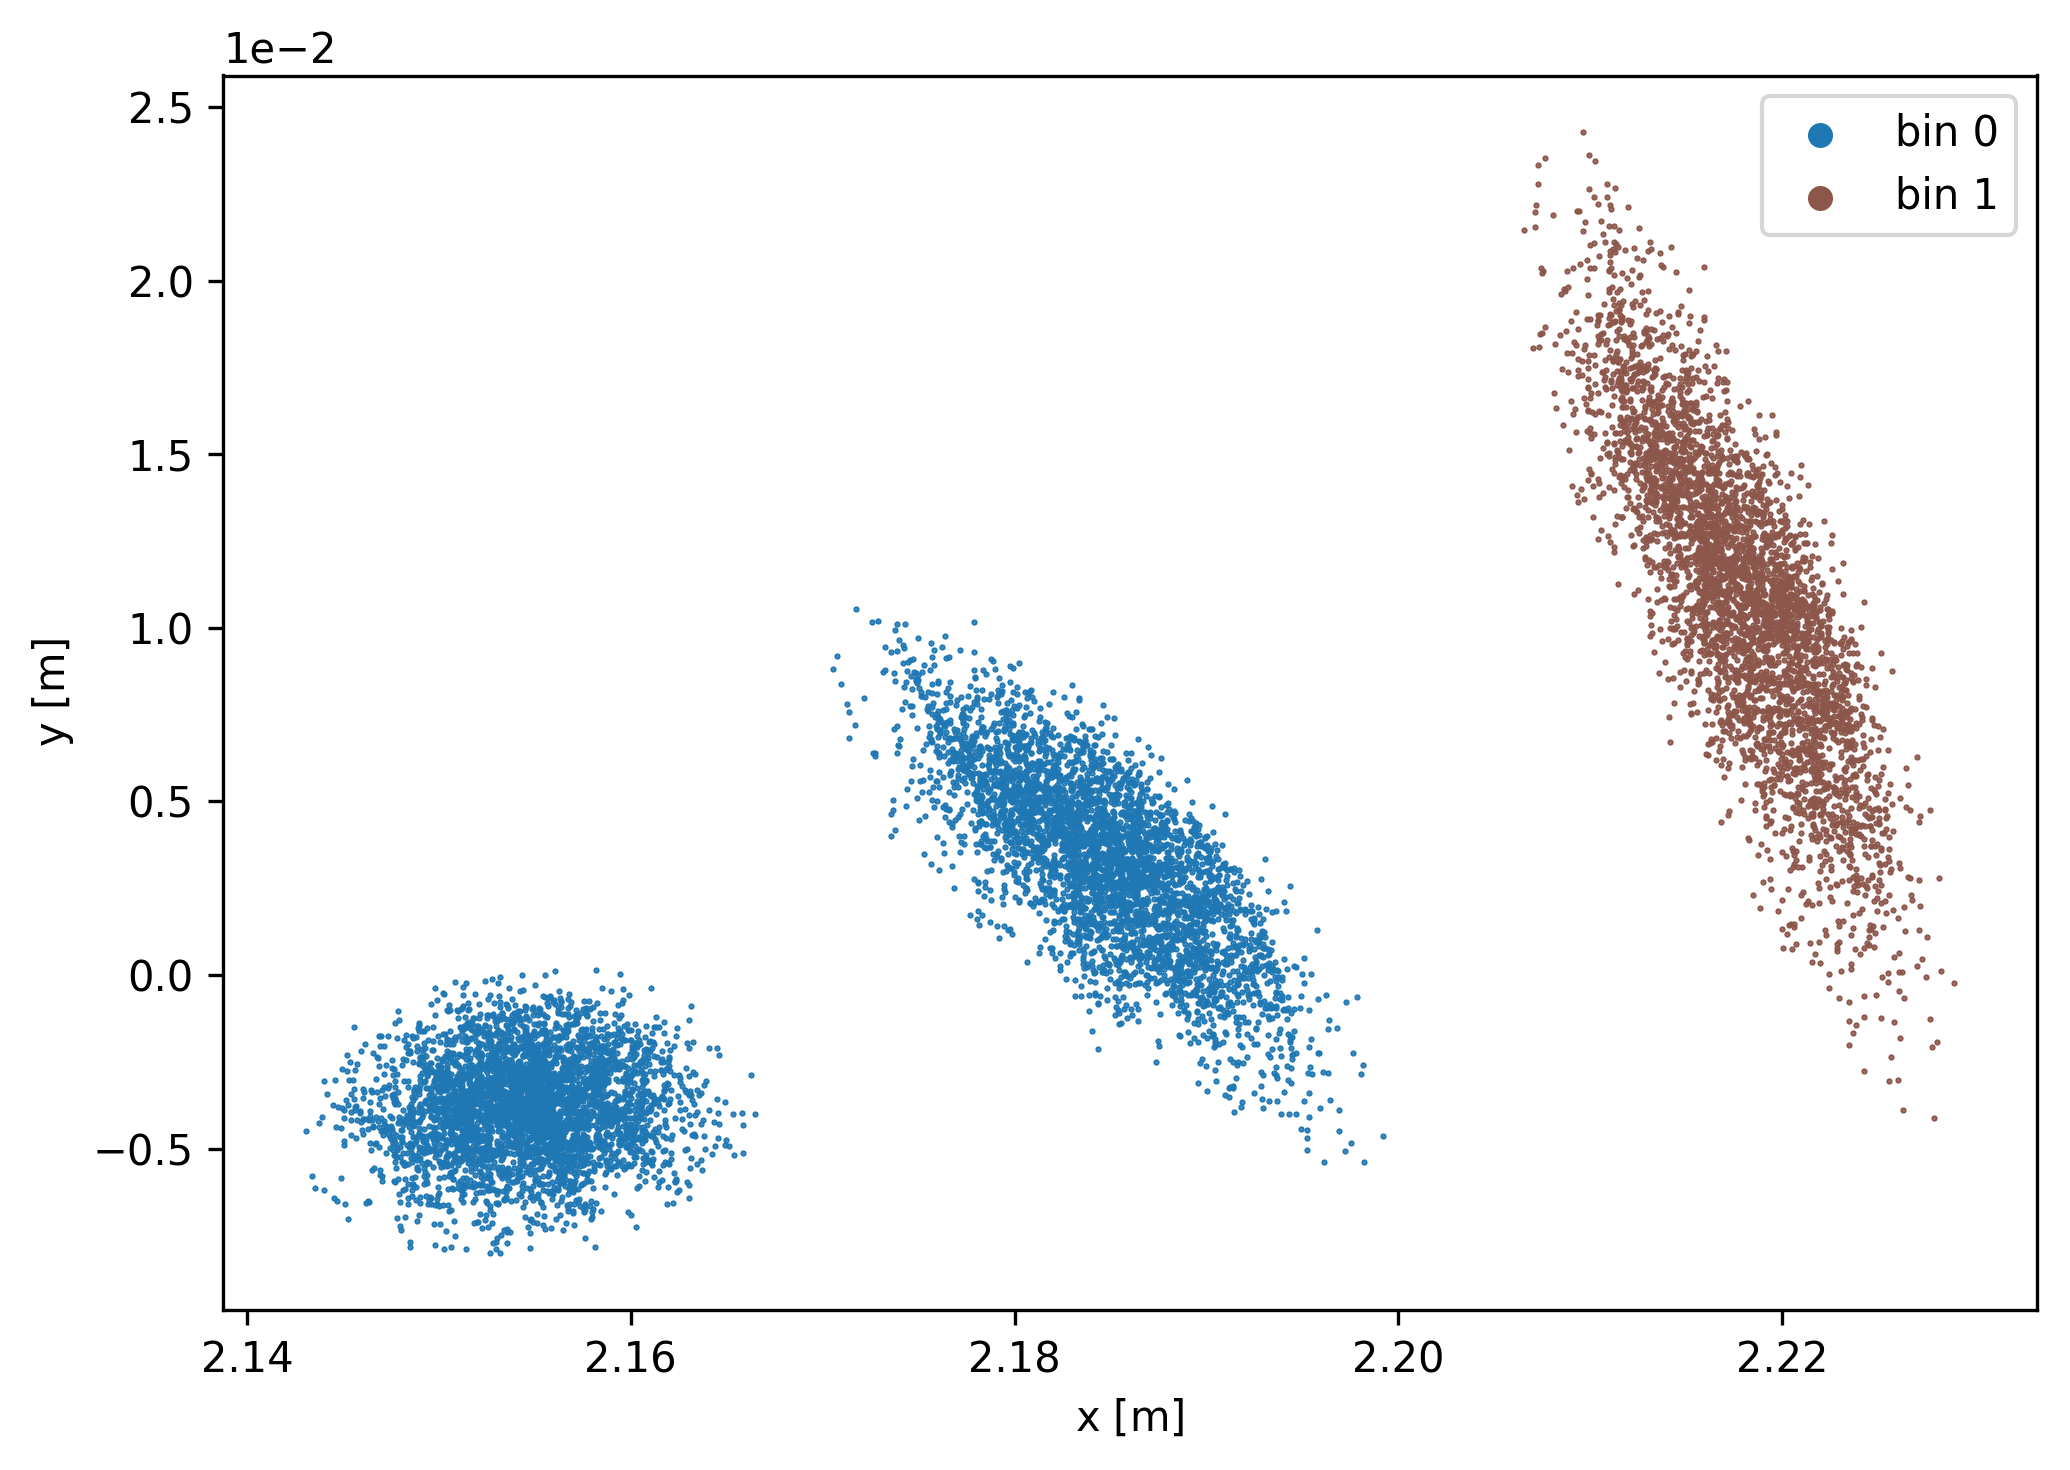

In [4]:
plt = plot_phase_space(dsets[0], 'x', 'y', xsci=True, ysci=True, step=3, bins=[0, 1])

plt.legend(['bin 0', 'bin 1'], markerscale=10)

plt.show()

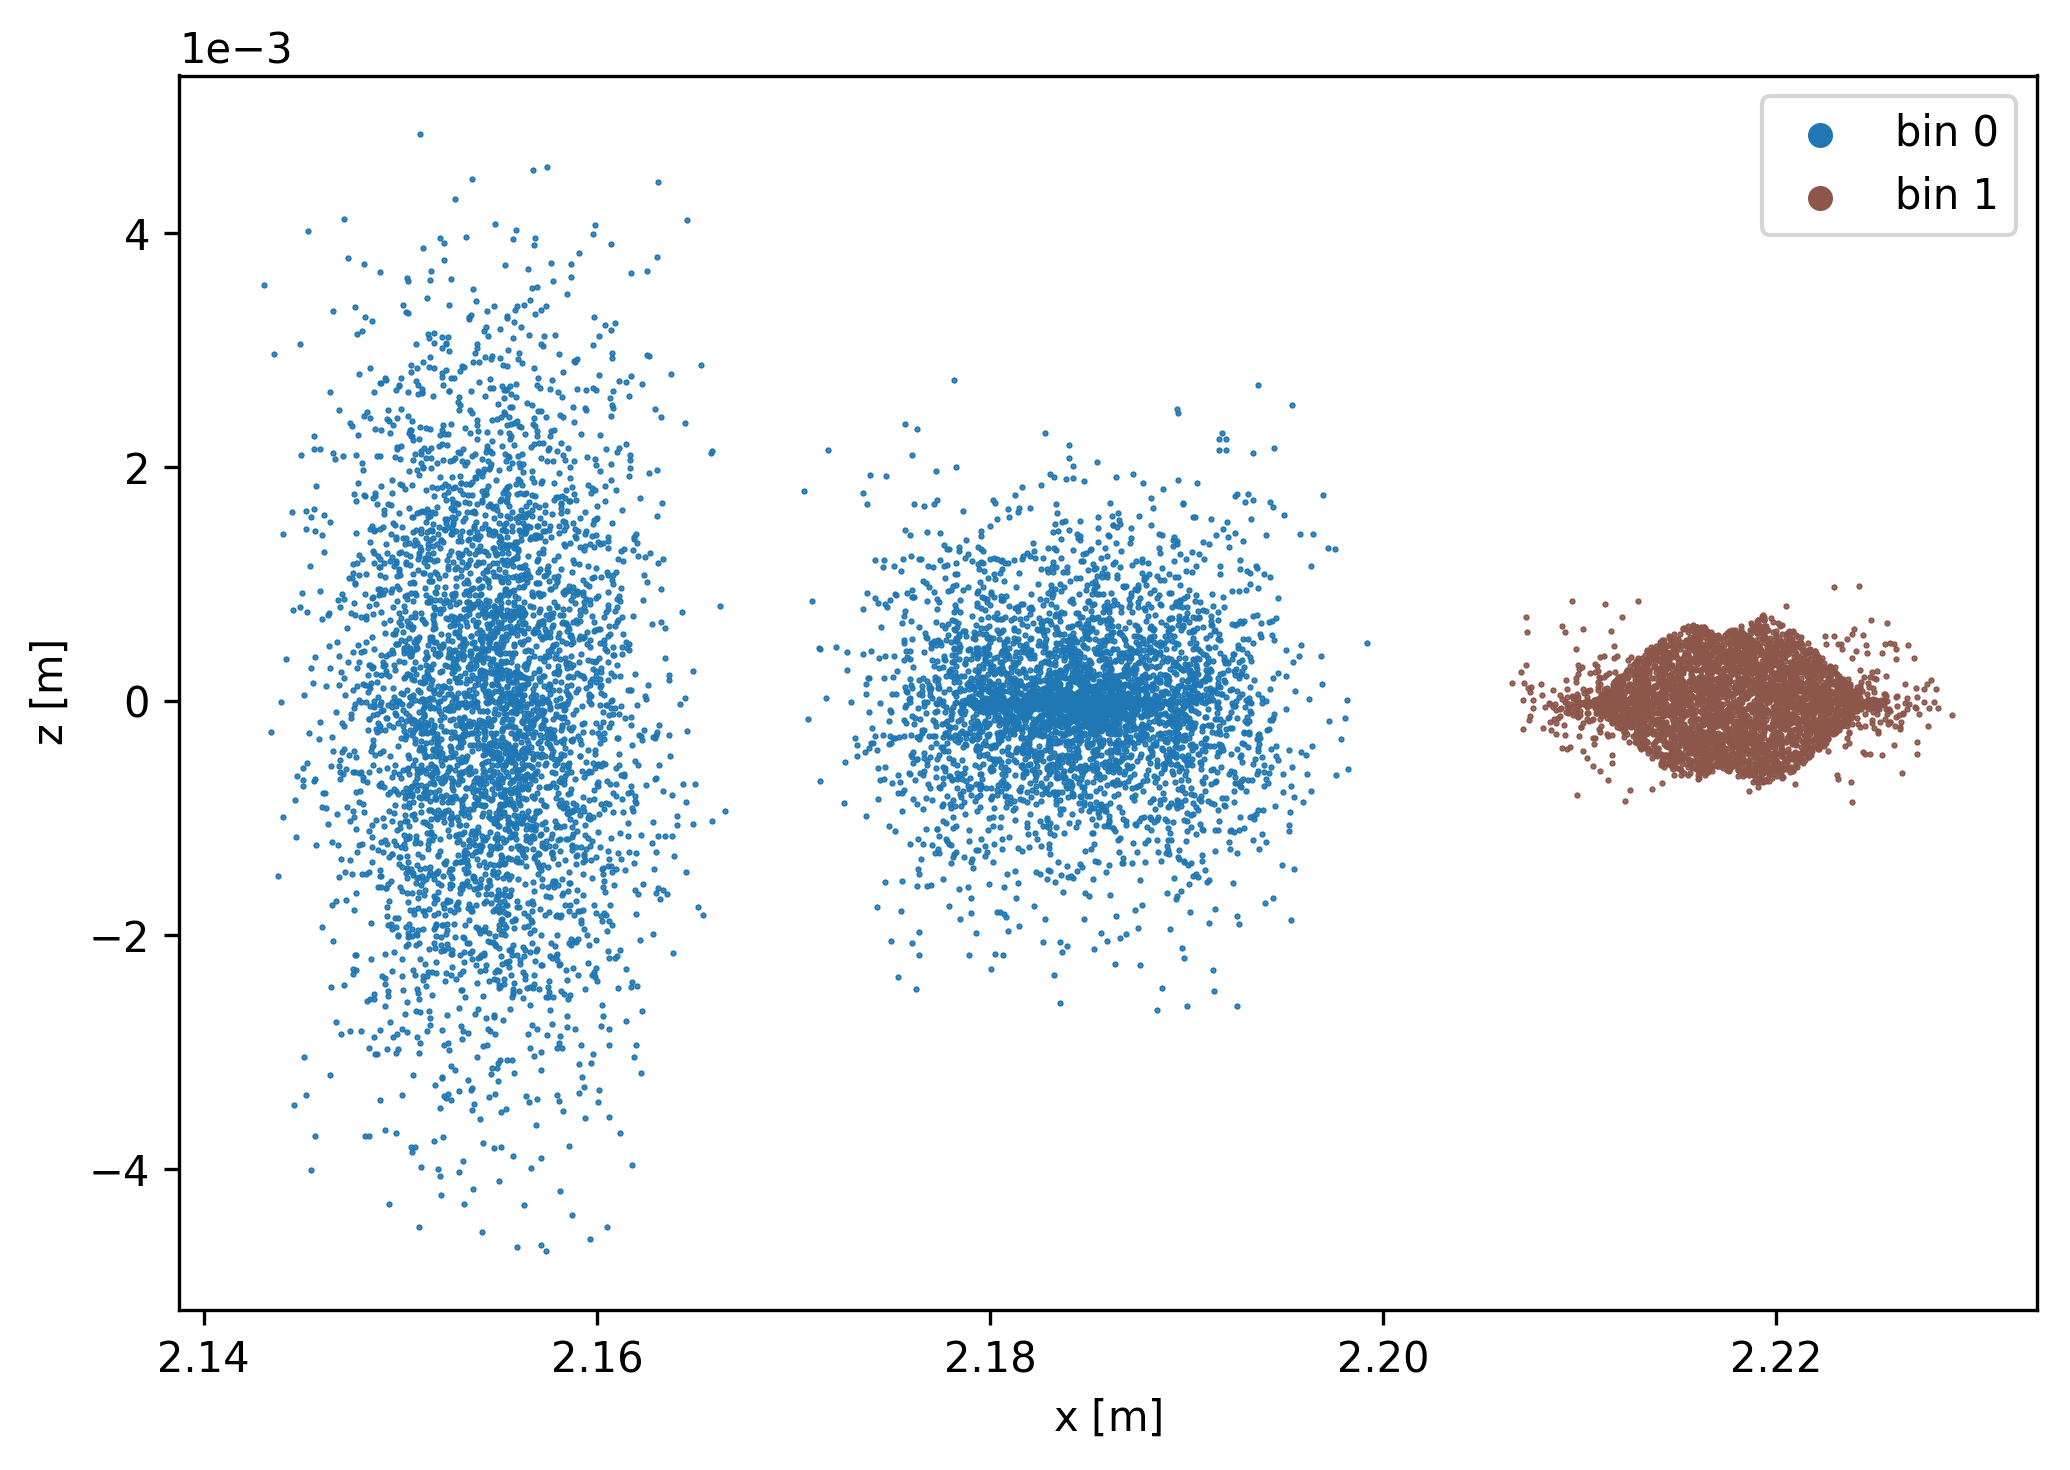

In [5]:
plt = plot_phase_space(dsets[0], 'x', 'z', xsci=True, ysci=True, step=3, bins=[0, 1])

plt.legend(['bin 0', 'bin 1'], markerscale=10)

plt.show()

In [6]:
from opal.statistics import statistics

try:
    print ( "Central moment:  " + str(statistics.moment(dsets[0], 'x', k=1, bin=1, step=3)) )
    
    print ( "Arithmetic mean: " + str(statistics.mean(dsets[0], 'x', bin=1, step=3)) )
    
    print ( "Skewness:        " + str(statistics.skew(dsets[0], 'x', bin=1, step=3)) )
    
    print ( "Kurtosis:        " + str(statistics.kurtosis(dsets[0], 'x', bin=1, step=3)) )
except Exception as e:
    print ( e )

Central moment:  0.0
Arithmetic mean: 2.21775770341
Skewness:        -0.07187704928121756
Kurtosis:        -0.07187704928121756


In [7]:
from opal.analysis import beam

minima = beam.find_beams(dsets[0], 'x', step=3)

print ( minima )

[2.1430608605003947, 2.1690516569482043, 2.2017553081076997, 2.2289509759140169]


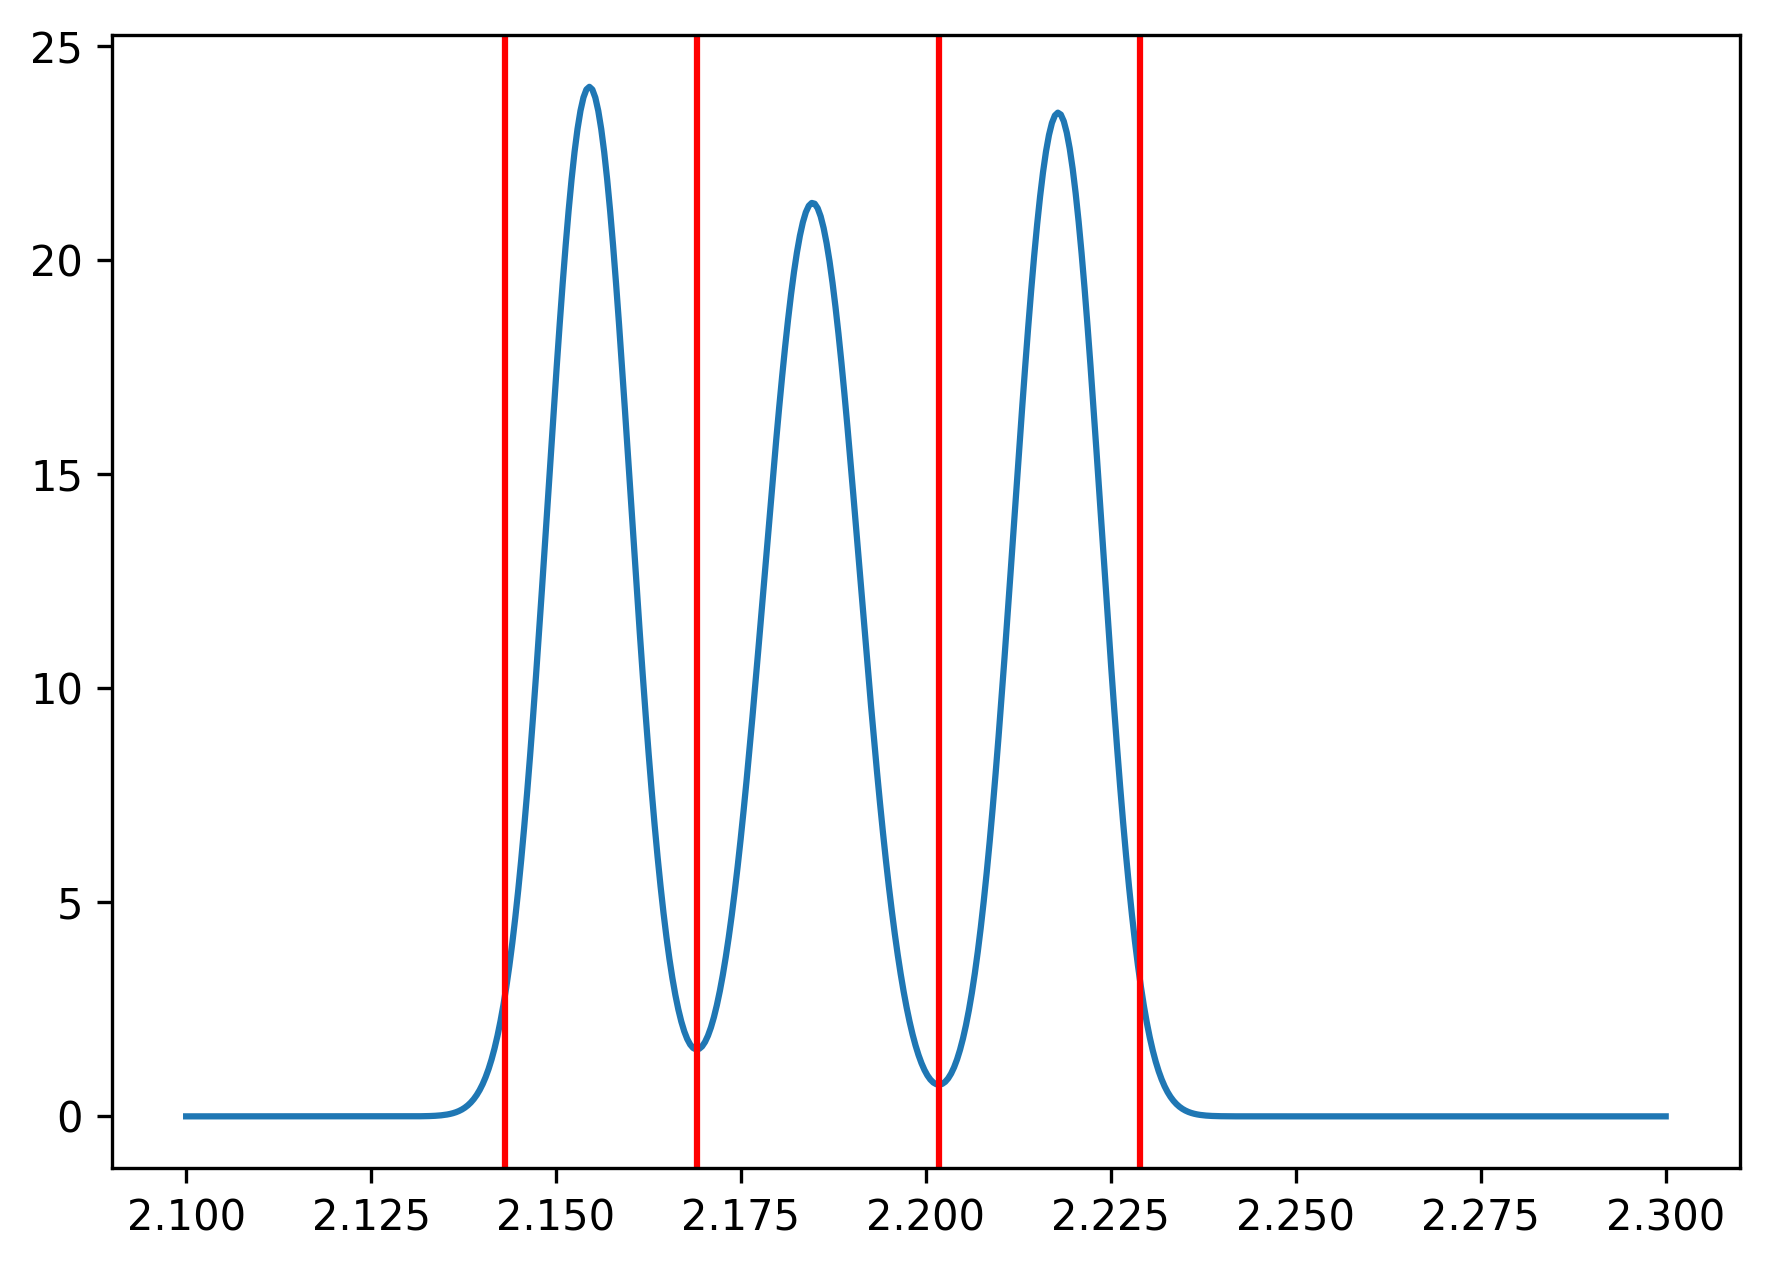

In [8]:
kde = statistics.gaussian_kde(dsets[0], 'x', step=3)

points = np.linspace(2.1, 2.3, 500)

pdf = kde.pdf(points)

plt.plot(points, pdf)

for m in minima:
    plt.axvline(m, color='r')
plt.show()

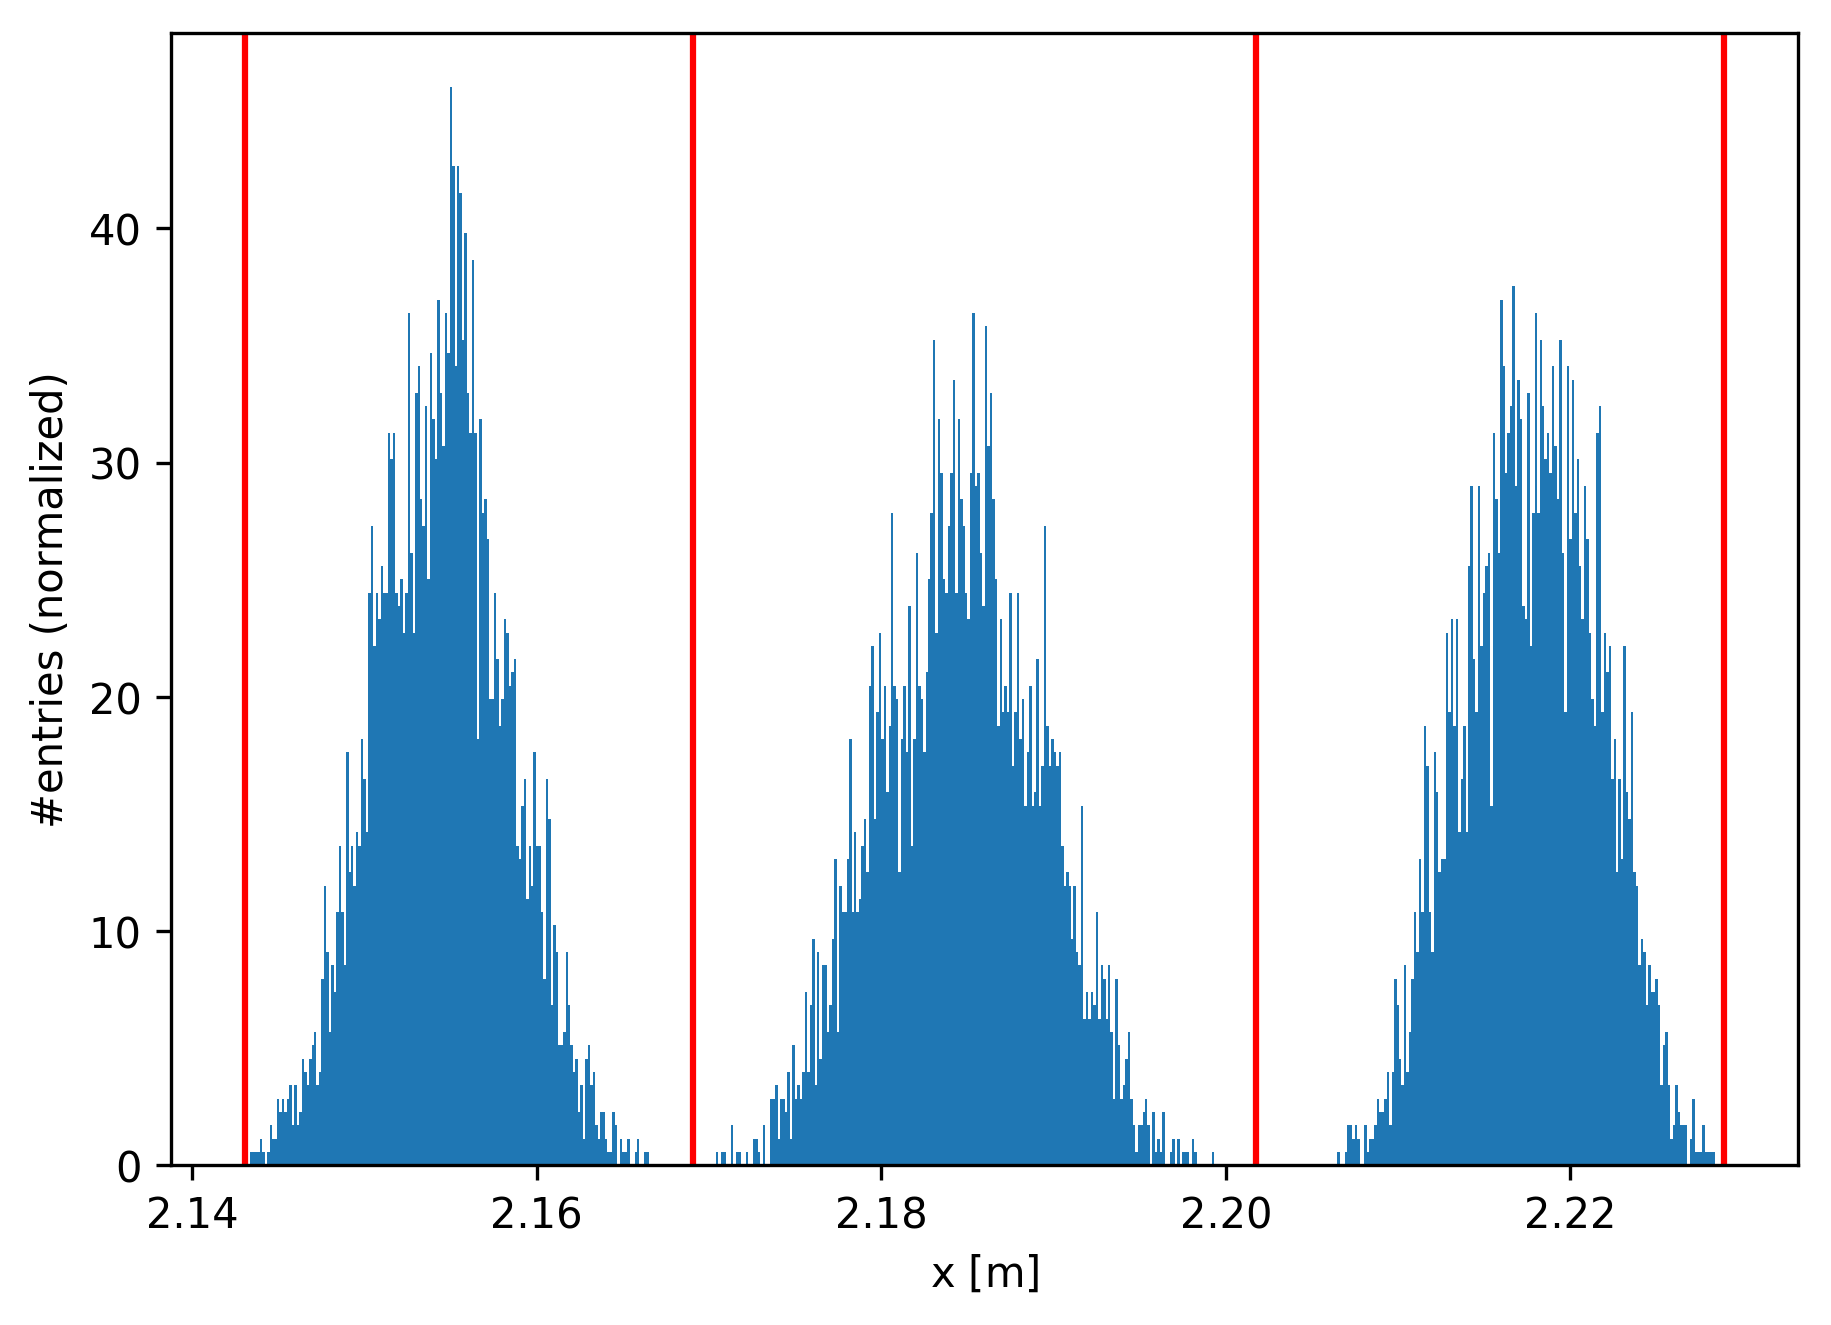

In [9]:
plt = plot_histogram(dsets[0], 'x', step=3, bins=600)

for m in minima:
    plt.axvline(m, color='r')
plt.show()

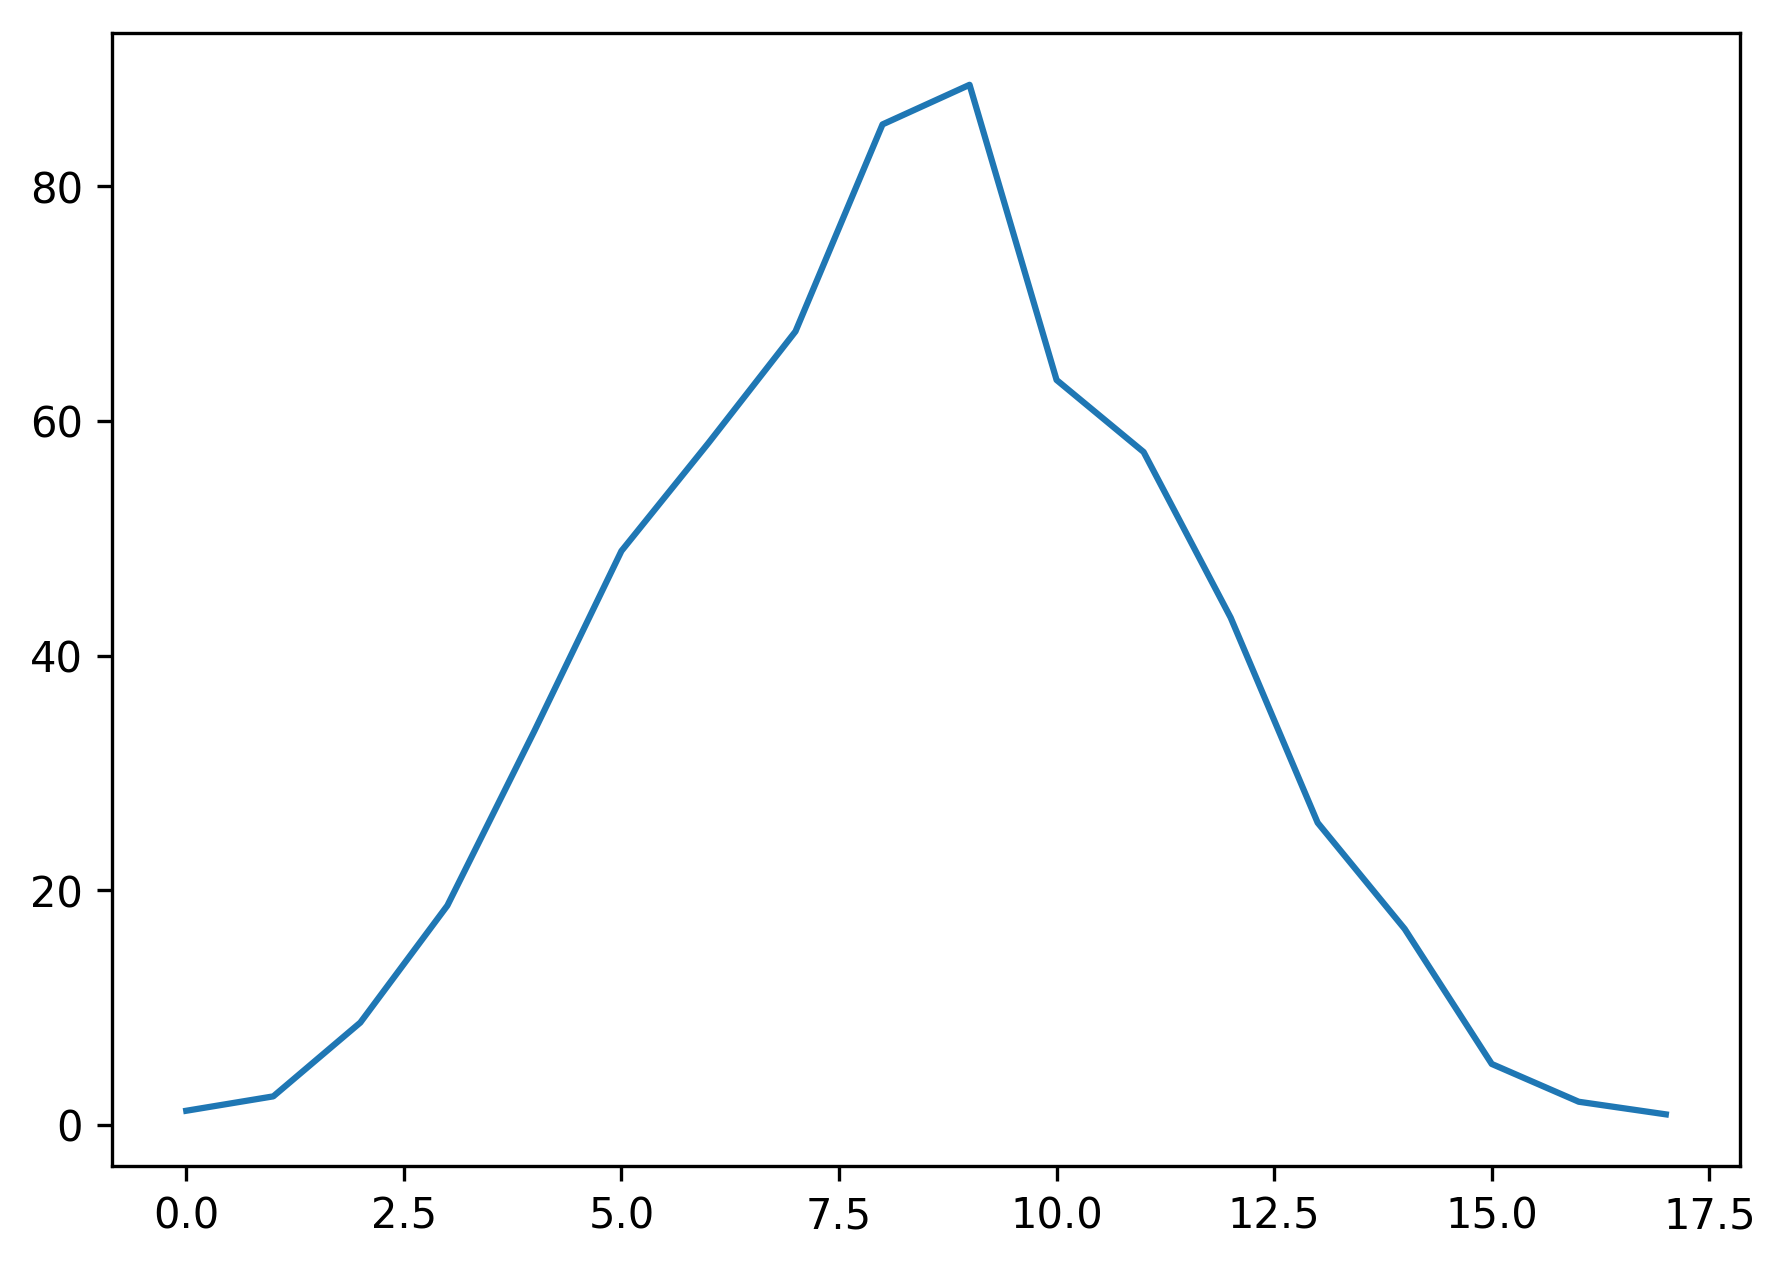

In [10]:
from opal.statistics import impl_statistics

try:
    data = beam.get_beam(dsets[0], 'x', step=3, k=1)

    hist, _ = impl_statistics.histogram(data, bins=18, density=True)
    
    plt.plot(hist)
    plt.show()
except Exception as e:
    print ( e )